# Relationships Between Cryptocurrencies Prices and Regulation Changes

Team: Piotr Brozek, Milan Joksimovic, Ashton Edakkunnathu, Usayd Hussein, Julius Salas

Github Repository Link: https://github.com/uic-ds-fall2025/class-project-standard-deviants.git

**Roles:**

**-Data Collection:** Piotr Brozek & Milan Joksimovic

**-Data Cleaning and Processing:** Ashton Edakkunnathu & Julius Salas

**-Exploratory Data Analysis:** Piotr Brozek & Milan Joksimovic

**-Data Visualization:** Ashton Edakkunnathu & Usayd Hussein

**-Machine Learning:** Julius Salas & Usayd Hussein

**Project Introduction**

In this project, we analyze the relationship between Bitcoin’s daily price movements and cryptocurrency regulation news. We use this data to answer questions such as: do days with regulation related news have different return distributions than days without such news? How does the number of news articles published on a day relate to the percent change of Bitcoin's value?

**Scope**

Our scope has changed since we submitted our proposal slides. We were intially planning on focusing on all major crypto currencies in the past 5-10 years to solely focusing on Bitcoin's history.



#Data Collection (APIs + Web Scraping): Piotr Brozek & Milan Joksimovic


Package Imports & Initial Setup

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns # follow README.md on how to install if not done already
import matplotlib.pyplot as plt
import yfinance as yf
import matplotlib.dates as mdates

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/My Drive/Colab Notebooks/418 Team Project - Cryptocurrency Trends"

In [ ]:
btc = pd.read_csv('cryptoData/BTC.csv')
#eth = pd.read_csv('cryptoData/Copy of ETH-USD.csv')

# Fetch BTC data from 12/1/2024 - 1/31/2025
btc_missing_data = yf.download("BTC-USD", start="2024-12-01", end="2025-02-01", interval="1d")

# Removes ticker from multi level column index
btc_missing_data.columns = btc_missing_data.columns.get_level_values(0)

# Reset index so Date is a column
btc_missing_data = btc_missing_data.reset_index();

# Rename columns to match our original data set
btc_missing_data = btc_missing_data.rename(columns={
    "Date": "date",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Volume": "Volume"
})

btc_missing_data = btc_missing_data.drop(columns=["Volume"])

# Adds ticker column and reorders existing columns to match btc dataset
btc_missing_data["ticker"] = "BTC"
btc_missing_data = btc_missing_data[["ticker", "date", "open", "high", "low", "close"]]

# Round data to match rounding in btc
btc_missing_data[['open', 'high', 'low', 'close']] = btc_missing_data[['open', 'high', 'low', 'close']].round(1)

# If the date is already found in btc, don't include it
btc_missing_data = btc_missing_data[~btc_missing_data['date'].isin(btc['date'])]

btc["date"] = pd.to_datetime(btc["date"])

# Merge our datasets together and sort by date
btc_full = pd.concat([btc, btc_missing_data], ignore_index=True)
btc_full = btc_full.sort_values(by='date').reset_index(drop=True)

btc_full[(btc_full['date'] >= '2024-12-10') & (btc_full['date'] <= '2025-01-26')]

/tmp/ipython-input-4050285277.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_missing_data = yf.download("BTC-USD", start="2024-12-01", end="2025-02-01", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4050285277.py:33: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  btc_missing_data = btc_missing_data[~btc_missing_data['date'].isin(btc['date'])]


,ticker,date,open,high,low,close
5260,BTC,2024-12-10,97441.2,98270.2,94321.3,96675.4
5261,BTC,2024-12-11,96656.1,101913.4,95747.2,101173.0
5262,BTC,2024-12-12,101167.8,102524.9,99340.0,100043.0
5263,BTC,2024-12-13,100046.6,101888.8,99233.3,101459.3
5264,BTC,2024-12-14,101451.4,102618.9,100634.1,101373.0
5265,BTC,2024-12-15,101373.5,105047.5,101227.0,104298.7
5266,BTC,2024-12-16,104293.6,107780.6,103323.0,106029.7
5267,BTC,2024-12-17,106030.7,108268.4,105291.7,106140.6
5268,BTC,2024-12-18,106147.3,106470.6,100041.5,100041.5
5269,BTC,2024-12-19,100070.7,102748.1,95587.7,97491.0


# NewsAPI

In [ ]:
%pip install newsapi-python
%pip install waybackpy

In [ ]:
import requests
import csv
import time
import random
from bs4 import BeautifulSoup
from datetime import datetime

# ==========================
# CONFIGURATION
# ==========================
base_cdx = "http://web.archive.org/cdx/search/cdx"
target_url = "https://www.coindesk.com/tag/regulation/"
from_year = 2014
to_year = 2020

event_keywords = {
    "regulation": ["regulation", "CFTC", "SEC", "law", "bill", "policy", "ban", "debate", "legal", "compliance", "framework", "oversight"],
    "exchange": ["wallet", "trades", "Coinbase", "enables", "instant", "launch", "deposit", "withdraw", "upgrade", "feature"],
    "legal_defense": ["defense", "lawyers", "court", "lawsuit", "legal", "filing", "settlement", "charge", "aggressive"],
    "conference": ["consensus", "summit", "conference", "meeting", "panel", "forum", "event", "talk"],
    "adoption": ["aid", "peace", "charity", "adoption", "donation", "nonprofit", "service", "usage", "acceptance", "encrypted", "cloud", "file sharing"],
    "price": ["crash", "drop", "plunge", "surge", "spike", "rally", "jump"]
}

output_csv = "crypto_regulation_articles_labeled.csv"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/140.0.0.0 Safari/537.36"
    )
}

# ==========================
# HELPERS
# ==========================
def safe_strip(value):
    try:
        return value.strip()
    except Exception:
        return "error"

def parse_date(raw_date, fallback_timestamp=None):
    if not raw_date:
        if fallback_timestamp:
            return f"{fallback_timestamp[:4]}-{fallback_timestamp[4:6]}-{fallback_timestamp[6:8]}"
        return "error"
    try:
        if "T" in raw_date and "-" in raw_date:
            return raw_date.split("T")[0]
        return datetime.strptime(raw_date.strip(), "%b %d, %Y").strftime("%Y-%m-%d")
    except Exception:
        if fallback_timestamp:
            return f"{fallback_timestamp[:4]}-{fallback_timestamp[4:6]}-{fallback_timestamp[6:8]}"
        return "error"

def label_article(text):
    text_lower = str(text).lower()
    labels = []
    for label, keywords in event_keywords.items():
        if any(k.lower() in text_lower for k in keywords):
            labels.append(label)
    return ", ".join(labels) if labels else "other"

# ==========================
# WAYBACK FUNCTIONS
# ==========================
def get_article_snapshots(url, from_year, to_year):
    params = {
        "url": url + "*",
        "output": "json",
        "from": str(from_year),
        "to": str(to_year),
        "filter": "statuscode:200"
    }
    res = requests.get(base_cdx, params=params, headers=HEADERS)
    res.raise_for_status()
    data = res.json()
    if len(data) <= 1:
        print("No snapshots found.")
        return []
    return data[1:]

# ==========================
# MAIN SCRAPING FUNCTION
# ==========================
def fetch_articles_from_listing(base_archive_url):
    all_articles = []
    visited_pages = set()
    next_pages = [base_archive_url]

    while next_pages:
        current_url = next_pages.pop(0)
        if current_url in visited_pages:
            continue
        visited_pages.add(current_url)

        print(f"🕸️ Scraping: {current_url}")
        try:
            res = requests.get(current_url, headers=HEADERS, timeout=25)
            res.raise_for_status()
            soup = BeautifulSoup(res.text, "html.parser")
        except Exception as e:
            print(f"⚠️ Failed to fetch {current_url}: {e}")
            continue

        # --- Common article containers across years ---
        article_divs = (
            soup.find_all("div", class_=["article", "post", "post-item", "card"])
            or soup.find_all("div", class_="list-item-wrapper")
        )

        for div in article_divs:
            title = snippet = url = pub_date_raw = ""

            # --- 2020+ FORMAT ---
            heading_tag = div.find("h4", class_="heading")
            if heading_tag:
                title = heading_tag.get_text(strip=True)
                a_tag = heading_tag.find_parent("a")
                if a_tag:
                    url = a_tag.get("href", "")

                snippet_tag = div.find("p", class_="card-text")
                if snippet_tag:
                    snippet = snippet_tag.get_text(strip=True)

                time_tag = div.find("time", class_="time")
                if time_tag:
                    pub_date_raw = time_tag.get_text(strip=True)

            # --- 2014–2019 FORMAT ---
            else:
                # handle older "article" containers like 2014 HTML
                h3_tag = div.find("h3")
                a_tag = None
                if h3_tag:
                    a_tag = h3_tag.find("a", class_="fade")
                if not a_tag:
                    a_tag = div.find("a", class_="fade") or div.find("a")

                if a_tag:
                    title = a_tag.get("title") or a_tag.get_text(strip=True)
                    url = a_tag.get("href", "")

                # description or snippet
                desc_tag = div.find("p", class_="desc") or div.find("p")
                if desc_tag:
                    snippet = desc_tag.get_text(strip=True)

                # publication date
                time_tag = div.find("time")
                if time_tag:
                    pub_date_raw = (
                        time_tag.get("datetime") or time_tag.get_text(strip=True)
                    )

            pub_date = parse_date(pub_date_raw, fallback_timestamp=current_url.split("/web/")[1][:8])

            all_articles.append({
                "title": safe_strip(title),
                "url": safe_strip(url),
                "snippet": safe_strip(snippet),
                "pub_date": safe_strip(pub_date)
            })

        # --- Pagination handling ---
        pagination_div = soup.find("div", class_="pagination")
        if pagination_div:
            for a in pagination_div.find_all("a", href=True):
                link = a["href"]
                if link.startswith("http") and "web.archive.org" in link and link not in visited_pages:
                    next_pages.append(link)

        # Polite delay
        time.sleep(random.uniform(4, 8))

    return all_articles


# ==========================
# MAIN SCRIPT
# ==========================
snapshots = get_article_snapshots(target_url, from_year, to_year)
print(f"🌐 Found {len(snapshots)} archived snapshots.\n")

with open(output_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["date", "title", "link", "snippet", "event_labels"])

    for snap in snapshots:

        timestamp, original_url = snap[1], snap[2]
        archive_url = f"https://web.archive.org/web/{timestamp}/{original_url}"

        print(f"\n=== 🗓️ Processing snapshot {timestamp} ===")
        articles = fetch_articles_from_listing(archive_url)
        print(f"✅ Found {len(articles)} articles for snapshot {timestamp}")

        for article in articles:
            text_to_check = article["title"] + " " + article["snippet"]
            labels = label_article(text_to_check)
            if labels != "other":
                writer.writerow([
                    article["pub_date"],
                    article["title"],
                    article["url"],
                    article["snippet"],
                    labels
                ])
                print(f"📰 {article['pub_date']}: {article['title']} [{labels}]\n🔗 {article['url']}\n")

        sleep_time = random.uniform(10, 20)
        print(f"😴 Sleeping for {sleep_time:.1f}s...\n")
        time.sleep(sleep_time)


In [ ]:
snapshots = get_article_snapshots(target_url, from_year, to_year)

print(f"🌐 Found {len(snapshots)} archived snapshots.\n")

# === Print snapshot timestamps and links ===
for snap in snapshots:
    timestamp = snap[1]
    original_url = snap[2]
    archive_url = f"https://web.archive.org/web/{timestamp}/{original_url}"
    print(f"🕒 {timestamp} → {archive_url}")

print("\n==============================\n")




In [ ]:

#import csv with news articles
df = pd.read_csv('full-reg-articles.csv')

df
#print size
#


,date,title,link,snippet,event_labels
0,2019-12-13,Bitcoin App Bottle Pay Shuts Down Over Impendi...,/web/20191231154441/https://www.coindesk.com/b...,"Bottle Pay is shutting down, citing the EU's n...","regulation, exchange"
1,2019-12-12,Netherlands Plans to Punish Crypto Scammers Wi...,/web/20191231154441/https://www.coindesk.com/n...,The Dutch government is about to get tougher w...,regulation
2,2019-12-11,SEC Taking ‘Measured’ Approach to Digital Asse...,/web/20191231154441/https://www.coindesk.com/s...,The chairman of the U.S. Securities and Exchan...,regulation
3,2019-12-11,China’s SEC May Soon Have a Crypto-Savvy Depar...,/web/20191231154441/https://www.coindesk.com/c...,China's securities watchdog is reported to be ...,regulation
4,2019-12-10,FinCEN Sees Jump in Crypto-Related Suspicious ...,/web/20191231154441/https://www.coindesk.com/f...,"Crypto companies have filed 7,100 Suspicious A...","regulation, conference, adoption, price"
...,...,...,...,...,...
5422,2018-12-11,The CFTC Wants to Learn More About Ethereum,/web/20200625234212/https://www.coindesk.com/t...,The CFTC has published a request for input to ...,regulation
5423,2018-12-04,Treasury Official: Global Regulators Must Foll...,/web/20200625234212/https://www.coindesk.com/t...,U.S. Treasury Department Under Secretary Sigal...,regulation
5424,2018-12-03,G20 Leaders Pledge Crypto-Asset Regulation Aft...,/web/20200625234212/https://www.coindesk.com/g...,G20 leaders declared that they would regulate ...,"regulation, conference"
5425,2018-10-29,Taiwanese Lawmaker Proposes New Business Categ...,/web/20200625234212/https://www.coindesk.com/t...,Taiwanese legislator Jason Hsu wants the islan...,"regulation, adoption"


#Data Cleaning & Preprocessing: Ashton Edakkunnathu & Julius Salas


Aligns both datasets on shared dates

In [ ]:

#btc_full contains bitcoin information from 7/17/10 to 10/04/25
btc_max_date = btc_full['date'].max()
btc_min_date = btc_full['date'].min()

print(f"BTC Max date: {btc_max_date}")
print(f"BTC Min date: {btc_min_date}")
print()

#sorted_news holds news information from 12/27/13 to 11/26/20
news_max_date = df['date'].max()
news_min_date = df['date'].min()

print(f"News Max date: {news_max_date}")
print(f"News Min date: {news_min_date}")
print()

#Aligns data sets on specific dates
news_df = df.sort_values(by='date').reset_index(drop=True)

btc_full['date'] = pd.to_datetime(btc_full['date'])
news_df['date'] = pd.to_datetime(news_df['date'])
btc_filtered = btc_full[(btc_full['date'] >= news_min_date) & (btc_full['date'] <= news_max_date)].copy()


BTC Max date: 2025-10-04 00:00:00
BTC Min date: 2010-07-17 00:00:00

News Max date: 2020-11-26
News Min date: 2013-12-27



Splits event labels into seperate columns and gets rid of unecessary columns

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

news_df['event_labels'] = news_df['event_labels'].fillna('')
news_df['event_labels_list'] = news_df['event_labels'].apply(
    lambda x: [e.strip() for e in x.split(',') if e.strip()]
)
news_df

mlb = MultiLabelBinarizer()
event_dummies = pd.DataFrame(
    mlb.fit_transform(news_df['event_labels_list']),
    columns=mlb.classes_,
    index=news_df.index
)

news_df = news_df.drop_duplicates(subset=['title', 'snippet'])
#news_df
news_df = pd.concat([news_df, event_dummies], axis=1)
news_df = news_df.loc[:, ~news_df.columns.duplicated()]

#get rid of duplicate articles for news df


keep_cols = ['date', 'adoption', 'conference', 'exchange', 'legal_defense', 'price', 'regulation']
clean_news_df = news_df[keep_cols]
clean_news_df

,date,adoption,conference,exchange,legal_defense,price,regulation
0,2013-12-27,1,0,0,0,0,0
1,2014-01-07,0,0,0,0,0,1
2,2014-01-08,1,0,0,0,0,0
3,2014-01-09,0,0,0,0,0,1
4,2014-01-09,1,0,0,0,0,1
...,...,...,...,...,...,...,...
5418,NaT,0,0,0,0,0,1
5420,NaT,1,0,0,0,0,1
5421,NaT,1,0,0,0,0,1
5423,NaT,0,0,0,1,0,1


Groups policy by dates and merges with btc data

In [ ]:
  #Groups policy by dates
event_cols = ['adoption', 'conference', 'exchange', 'legal_defense', 'price', 'regulation']
daily_news = clean_news_df.groupby('date')[event_cols].sum().reset_index()

#Merges with btc data to make one big table
merged = pd.merge(btc_filtered, daily_news, on='date', how='left')
merged[event_cols] = merged[event_cols].fillna(0)
merged

,ticker,date,open,high,low,close,adoption,conference,exchange,legal_defense,price,regulation
0,BTC,2013-12-27,801.98,836.83,767.87,803.05,1.0,0.0,0.0,0.0,0.0,0.0
1,BTC,2013-12-28,803.05,805.97,715.60,761.99,0.0,0.0,0.0,0.0,0.0,0.0
2,BTC,2013-12-29,761.99,803.95,734.98,784.96,0.0,0.0,0.0,0.0,0.0,0.0
3,BTC,2013-12-30,784.96,818.83,780.96,804.83,0.0,0.0,0.0,0.0,0.0,0.0
4,BTC,2013-12-31,804.83,813.94,776.96,805.94,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2522,BTC,2020-11-22,18631.50,18756.30,17644.30,18627.70,0.0,0.0,0.0,0.0,0.0,0.0
2523,BTC,2020-11-23,18575.40,18693.50,18029.70,18421.20,0.0,0.0,0.0,1.0,0.0,1.0
2524,BTC,2020-11-24,18422.30,19418.40,18129.20,19126.90,0.0,0.0,0.0,1.0,0.0,0.0
2525,BTC,2020-11-25,19124.00,19487.40,18647.80,18777.40,0.0,0.0,0.0,0.0,0.0,0.0


Making percent change and range column

In [ ]:
#Adds percent change column
merged['percent_change'] = ((merged['close'] - merged['open']) / merged['open']) * 100

#Adds the range column
merged['range'] = (merged['high'] - merged['low']) / merged['low']

merged

,ticker,date,open,high,low,close,adoption,conference,exchange,legal_defense,price,regulation,percent_change,range
0,BTC,2013-12-27,801.98,836.83,767.87,803.05,1.0,0.0,0.0,0.0,0.0,0.0,0.133420,0.089807
1,BTC,2013-12-28,803.05,805.97,715.60,761.99,0.0,0.0,0.0,0.0,0.0,0.0,-5.113007,0.126286
2,BTC,2013-12-29,761.99,803.95,734.98,784.96,0.0,0.0,0.0,0.0,0.0,0.0,3.014475,0.093839
3,BTC,2013-12-30,784.96,818.83,780.96,804.83,0.0,0.0,0.0,0.0,0.0,0.0,2.531339,0.048492
4,BTC,2013-12-31,804.83,813.94,776.96,805.94,0.0,0.0,0.0,0.0,0.0,0.0,0.137917,0.047596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2522,BTC,2020-11-22,18631.50,18756.30,17644.30,18627.70,0.0,0.0,0.0,0.0,0.0,0.0,-0.020396,0.063023
2523,BTC,2020-11-23,18575.40,18693.50,18029.70,18421.20,0.0,0.0,0.0,1.0,0.0,1.0,-0.830130,0.036817
2524,BTC,2020-11-24,18422.30,19418.40,18129.20,19126.90,0.0,0.0,0.0,1.0,0.0,0.0,3.824712,0.071112
2525,BTC,2020-11-25,19124.00,19487.40,18647.80,18777.40,0.0,0.0,0.0,0.0,0.0,0.0,-1.812382,0.045024


Adds columns based on policy prescence, sum of policies per day, and whether a policy was enacted in the past 1-3 days.

In [ ]:
# Checks IF a policy was enacted that day
merged['news_event_happened'] = (merged[event_cols].sum(axis=1) > 0).astype(int)

# Counts the number of policies enacted that day?
merged['news_events_count'] = merged[event_cols].sum(axis=1)

# Looks at policy lag, ie - if a policy was enacted in the days leading up to that particular day
merged['news_event_lag1'] = merged['news_event_happened'].shift(1)
merged['news_event_lag2'] = merged['news_event_happened'].shift(2)
merged['news_event_lag3'] = merged['news_event_happened'].shift(3)

# Replace all NaN values with 0
merged = merged.fillna(0)

data = merged.copy()
data

,ticker,date,open,high,low,close,adoption,conference,exchange,legal_defense,price,regulation,percent_change,range,news_event_happened,news_events_count,news_event_lag1,news_event_lag2,news_event_lag3
0,BTC,2013-12-27,801.98,836.83,767.87,803.05,1.0,0.0,0.0,0.0,0.0,0.0,0.133420,0.089807,1,1.0,0.0,0.0,0.0
1,BTC,2013-12-28,803.05,805.97,715.60,761.99,0.0,0.0,0.0,0.0,0.0,0.0,-5.113007,0.126286,0,0.0,1.0,0.0,0.0
2,BTC,2013-12-29,761.99,803.95,734.98,784.96,0.0,0.0,0.0,0.0,0.0,0.0,3.014475,0.093839,0,0.0,0.0,1.0,0.0
3,BTC,2013-12-30,784.96,818.83,780.96,804.83,0.0,0.0,0.0,0.0,0.0,0.0,2.531339,0.048492,0,0.0,0.0,0.0,1.0
4,BTC,2013-12-31,804.83,813.94,776.96,805.94,0.0,0.0,0.0,0.0,0.0,0.0,0.137917,0.047596,0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2522,BTC,2020-11-22,18631.50,18756.30,17644.30,18627.70,0.0,0.0,0.0,0.0,0.0,0.0,-0.020396,0.063023,0,0.0,0.0,0.0,0.0
2523,BTC,2020-11-23,18575.40,18693.50,18029.70,18421.20,0.0,0.0,0.0,1.0,0.0,1.0,-0.830130,0.036817,1,2.0,0.0,0.0,0.0
2524,BTC,2020-11-24,18422.30,19418.40,18129.20,19126.90,0.0,0.0,0.0,1.0,0.0,0.0,3.824712,0.071112,1,1.0,1.0,0.0,0.0
2525,BTC,2020-11-25,19124.00,19487.40,18647.80,18777.40,0.0,0.0,0.0,0.0,0.0,0.0,-1.812382,0.045024,0,0.0,1.0,1.0,0.0


#Exploratory Data Analysis: Piotr Brozek & Milan Joksimovic


In [ ]:
import pandas as pd

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2527 entries, 0 to 2526
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ticker               2527 non-null   object        
 1   date                 2527 non-null   datetime64[ns]
 2   open                 2527 non-null   float64       
 3   high                 2527 non-null   float64       
 4   low                  2527 non-null   float64       
 5   close                2527 non-null   float64       
 6   adoption             2527 non-null   float64       
 7   conference           2527 non-null   float64       
 8   exchange             2527 non-null   float64       
 9   legal_defense        2527 non-null   float64       
 10  price                2527 non-null   float64       
 11  regulation           2527 non-null   float64       
 12  percent_change       2527 non-null   float64       
 13  range                2527 non-nul

In [ ]:
data.describe()


,date,open,high,low,close,adoption,conference,exchange,legal_defense,price,regulation,percent_change,range,news_event_happened,news_events_count,news_event_lag1,news_event_lag2,news_event_lag3
count,2527,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000
mean,2017-06-12 00:00:00,4235.277190,4352.406977,4106.409699,4241.908983,0.035615,0.020973,0.021369,0.031262,0.003562,0.173328,0.311400,0.060408,0.163435,0.286110,0.163039,0.163039,0.162643
min,2013-12-27 00:00:00,111.560000,160.150000,91.660000,111.560000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-57.205674,0.004919,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015-09-19 12:00:00,452.370000,460.445000,442.010000,452.370000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.240618,0.024020,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2017-06-12 00:00:00,2424.610000,2530.340000,2303.340000,2442.460000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.129851,0.039759,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2019-03-05 12:00:00,7858.775000,8108.680000,7599.200000,7876.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.709098,0.067822,0.000000,0.000000,0.000000,0.000000,0.000000
max,2020-11-26 00:00:00,19346.600000,19870.600000,18750.900000,19345.500000,2.000000,2.000000,2.000000,2.000000,1.000000,5.000000,336.839004,3.787156,1.000000,7.000000,1.000000,1.000000,1.000000
std,NaN,4309.148776,4437.617828,4160.911768,4316.513445,0.195753,0.148746,0.152631,0.178551,0.059584,0.458094,8.315851,0.114392,0.369835,0.780336,0.369475,0.369475,0.369113


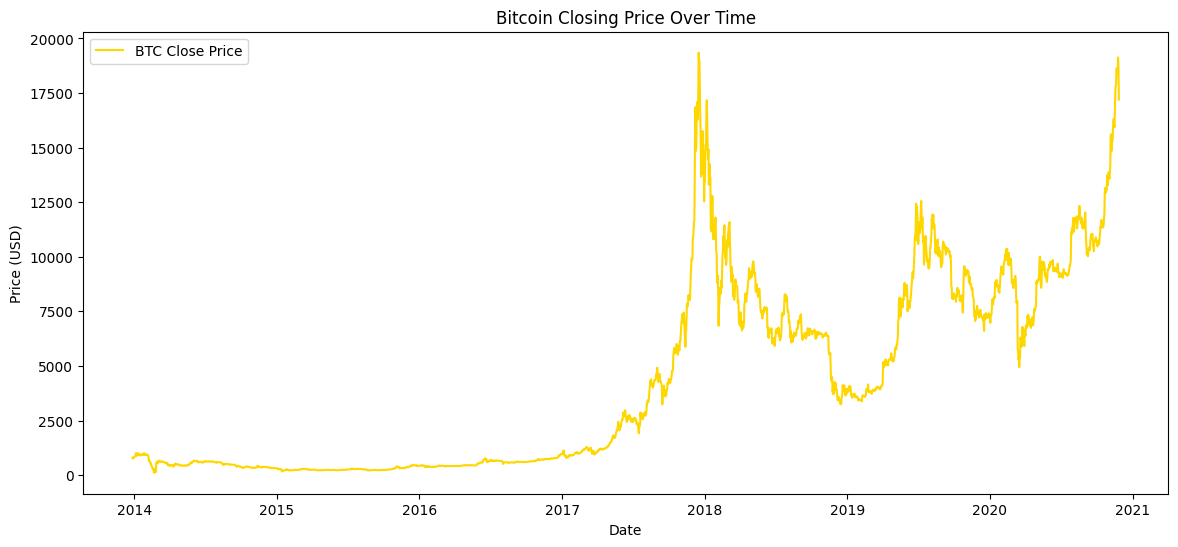

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(data['date'], data['close'], label='BTC Close Price', color='gold')
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


#Does The News Affect Daily  BTC % change?

         count      mean    median        std        min         max
No News   2114  0.233339  0.140846   4.948225 -43.901731  129.105414
News       413  0.710968  0.069421  17.269000 -57.205674  336.839004


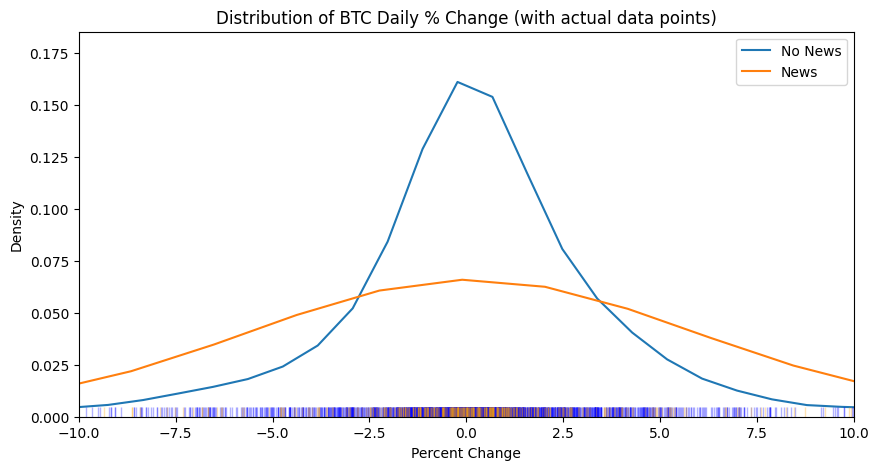

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

# KDEs with rug
sns.kdeplot(data.loc[data['news_event_happened']==0, 'percent_change'], label='No News')
sns.kdeplot(data.loc[data['news_event_happened']==1, 'percent_change'], label='News')

# Rug plots (actual data points along x-axis)
sns.rugplot(data.loc[data['news_event_happened']==0, 'percent_change'], color='blue', alpha=0.3)
sns.rugplot(data.loc[data['news_event_happened']==1, 'percent_change'], color='orange', alpha=0.3)

# Group by news event and compute summary statistics
summary = data.groupby('news_event_happened')['percent_change'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
summary.index = ['No News', 'News']  # make index more readable
print(summary)

plt.xlim(-10, 10)
plt.title('Distribution of BTC Daily % Change (with actual data points)')
plt.xlabel('Percent Change')
plt.ylabel('Density')
plt.legend()
plt.show()


On average, BTC shows slightly higher gains on news days (0.71%) compared to no-news days (0.23%), suggesting that news events may push the market upward, though this effect is small relative to overall volatility. News days are significantly more volatile, with a standard deviation of ~17.27% versus ~4.95% on no-news days. Extreme price movements occur in both cases, but news days exhibit much larger swings, ranging from a 57.2% loss to a 336.8% gain, compared to -43.9% to 129.1% on no-news days. These large fluctuations on news days contribute to both the higher average gain and the increased volatility.

# Overall statistics for regulation-related events and percent changes:

In [ ]:
# Summary stats
reg_summary = data.groupby('regulation')['percent_change'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print(reg_summary)


            count      mean    median        std        min         max
regulation                                                             
0.0          2159  0.239014  0.142041   4.926175 -43.901731  129.105414
1.0           307  1.191993  0.129851  19.595374 -27.230579  336.839004
2.0            56 -1.845982 -0.404086   8.826546 -57.205674   10.962064
3.0             2  2.761212  2.761212   1.537150   1.674282    3.848141
4.0             2  0.251827  0.251827   1.463131  -0.782764    1.286417
5.0             1  2.283164  2.283164        NaN   2.283164    2.283164


# Does the amount of articles in a day effect the value of BTC?

No Regulation News:
  Count of days: 2159.0
  Average daily percent change: 0.24%
  Median daily percent change: 0.14%
  Volatility (standard deviation): 4.93%
  Minimum daily percent change: -43.90%
  Maximum daily percent change: 129.11%

Regulation News:
  Count of days: 368.0
  Average daily percent change: 0.74%
  Median daily percent change: 0.03%
  Volatility (standard deviation): 18.25%
  Minimum daily percent change: -57.21%
  Maximum daily percent change: 336.84%



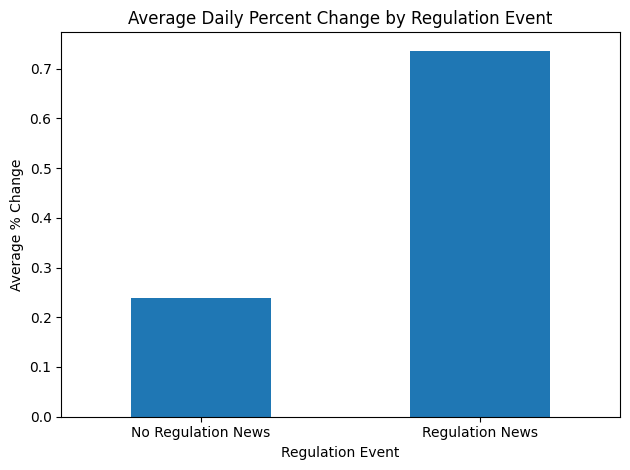

In [ ]:
# Ensure regulation is binary
data['regulation_binary'] = data['regulation'].apply(lambda x: 1 if x > 0 else 0)

# Summary statistics for percent changes by regulation event
reg_summary = data.groupby('regulation_binary')['percent_change'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
)
reg_summary.index = ['No Regulation News', 'Regulation News']  # readable labels

# Print clearly with percentage sign in the description
for idx, row in reg_summary.iterrows():
    print(f"{idx}:")
    print(f"  Count of days: {row['count']}")
    print(f"  Average daily percent change: {row['mean']:.2f}%")
    print(f"  Median daily percent change: {row['median']:.2f}%")
    print(f"  Volatility (standard deviation): {row['std']:.2f}%")
    print(f"  Minimum daily percent change: {row['min']:.2f}%")
    print(f"  Maximum daily percent change: {row['max']:.2f}%\n")

import matplotlib.pyplot as plt

# Bar chart of mean percent change
reg_summary['mean'].plot(kind='bar')

plt.title("Average Daily Percent Change by Regulation Event")
plt.ylabel("Average % Change")
plt.xlabel("Regulation Event")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()




In [ ]:
clean_summary = {}

for label, group in data.groupby('regulation_binary'):
    # Remove outliers
    group_no_outliers = group['percent_change'].copy()
    Q1 = group_no_outliers.quantile(0.25)
    Q3 = group_no_outliers.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    group_no_outliers = group_no_outliers[(group_no_outliers >= lower) & (group_no_outliers <= upper)]

    clean_summary[label] = {
        'count': len(group_no_outliers),
        'mean': group_no_outliers.mean(),
        'median': group_no_outliers.median(),
        'std': group_no_outliers.std(),
        'min': group_no_outliers.min(),
        'max': group_no_outliers.max()
    }

# Pretty print
for idx, stats in clean_summary.items():
    idx_label = 'No Regulation News' if idx == 0 else 'Regulation News'
    print(f"{idx_label}:")
    print(f"  Count of days: {stats['count']}")
    print(f"  Average daily percent change (no outliers): {stats['mean']:.2f}%")
    print(f"  Median daily percent change (no outliers): {stats['median']:.2f}%")
    print(f"  Volatility (std, no outliers): {stats['std']:.2f}%")
    print(f"  Minimum daily percent change (no outliers): {stats['min']:.2f}%")
    print(f"  Maximum daily percent change (no outliers): {stats['max']:.2f}%\n")


No Regulation News:
  Count of days: 1929
  Average daily percent change (no outliers): 0.26%
  Median daily percent change (no outliers): 0.17%
  Volatility (std, no outliers): 2.27%
  Minimum daily percent change (no outliers): -5.69%
  Maximum daily percent change (no outliers): 6.18%

Regulation News:
  Count of days: 325
  Average daily percent change (no outliers): 0.09%
  Median daily percent change (no outliers): 0.03%
  Volatility (std, no outliers): 2.02%
  Minimum daily percent change (no outliers): -5.09%
  Maximum daily percent change (no outliers): 5.22%



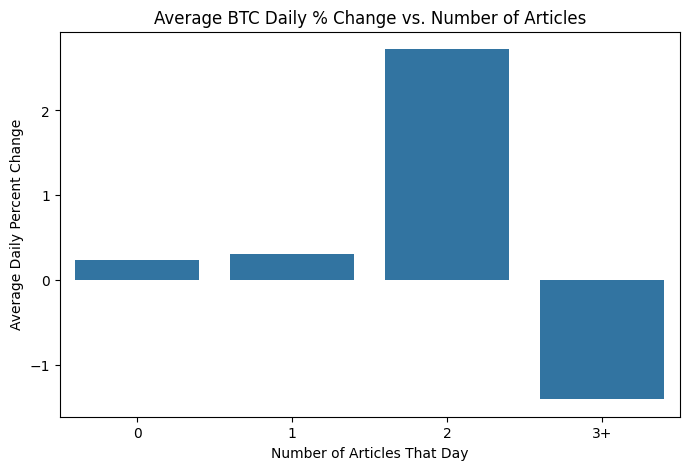

In [ ]:
plot_df = data.copy()

def bucket_articles(n):
    if n == 0:
        return '0'
    elif n == 1:
        return '1'
    elif n == 2:
        return '2'
    else:
        return '3+'

plot_df['article_bin'] = plot_df['news_events_count'].apply(bucket_articles)

plot_df['abs_change'] = plot_df['percent_change'].abs()

agg = (
    plot_df
    .groupby('article_bin')['percent_change']
    .agg(['mean', 'median', 'count'])
    .reindex(['0', '1', '2', '3+'])
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=agg.index,
    y=agg['mean']
)
plt.title('Average BTC Daily % Change vs. Number of Articles')
plt.xlabel('Number of Articles That Day')
plt.ylabel('Average Daily Percent Change')
plt.show()

Our exploratory analysis of Bitcoin daily percent changes shows that regulation news can cause rare but extreme price movements, resulting in large spikes or drops that appear as outliers in the data. For the majority of days(~85% of the time), BTC’s daily changes are modest, and the typical movement on regulation news days is very similar to non-news days once outliers are removed.

The bar chart of average daily percent change by number of articles reinforces this pattern: days with 0–1 articles have small, positive average returns, while days with exactly 2 articles show a noticeably higher average gain, and days with 3 or more articles have a negative average driven by only a handful of extreme events.

Taken together, these results indicate that while regulatory announcements can produce significant short term volatility, their impact on typical day to day returns is limited. Since we only had 15% of days with regulation news, over time, the few very large moves average out, so regulation events matter primarily as sources of occasional large swings rather than as forces that consistently change Bitcoin’s usual daily price behavior.

#Visualizations: Ashton Edakkunnathu & Usayd Hussein

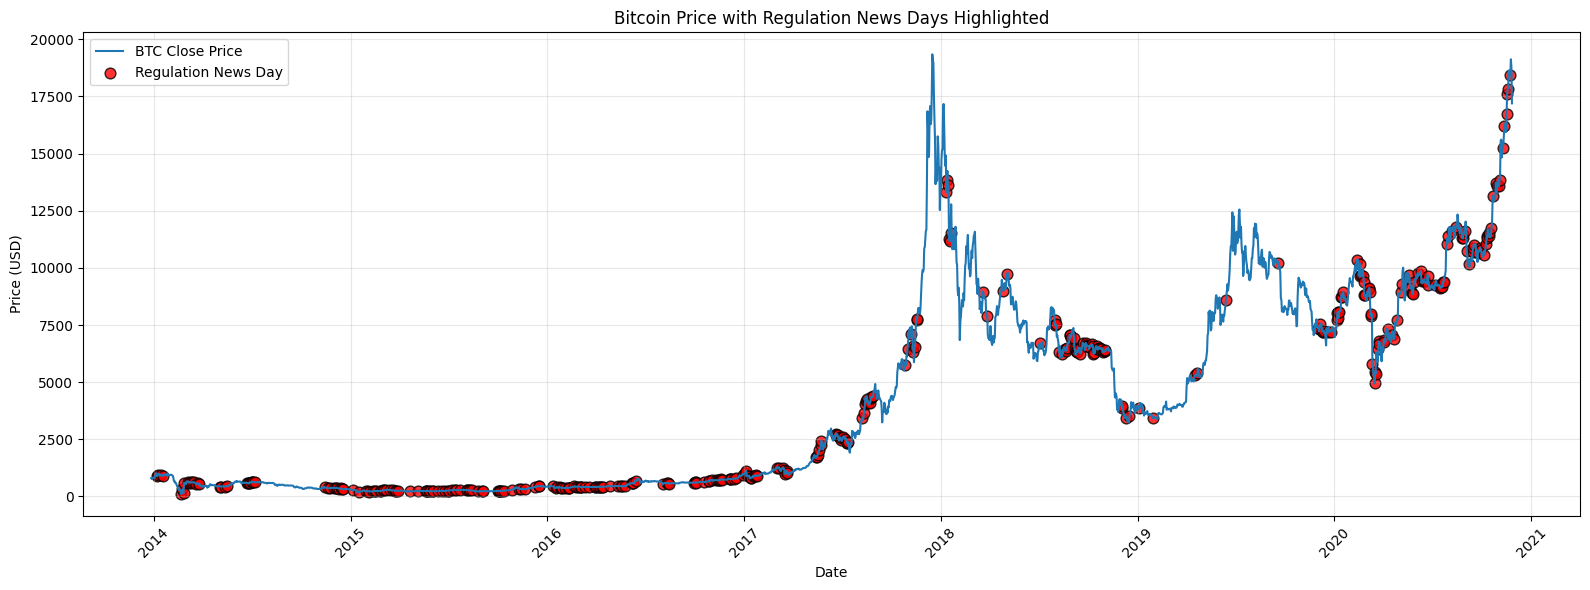

In [ ]:


# Days where at least one regulation event occurred
regulation_days = data[data['regulation'] > 0]

fig, ax = plt.subplots(figsize=(16, 6))

# BTC price line
ax.plot(data['date'], data['close'], label='BTC Close Price')

# Markers on regulation days
ax.scatter(
    regulation_days['date'],
    regulation_days['close'],
    s=60,
    marker='o',
    edgecolor='black',
    facecolor='red',
    label='Regulation News Day',
    alpha=0.8
)

ax.set_title('Bitcoin Price with Regulation News Days Highlighted')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.grid(True, alpha=0.3)
ax.legend()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

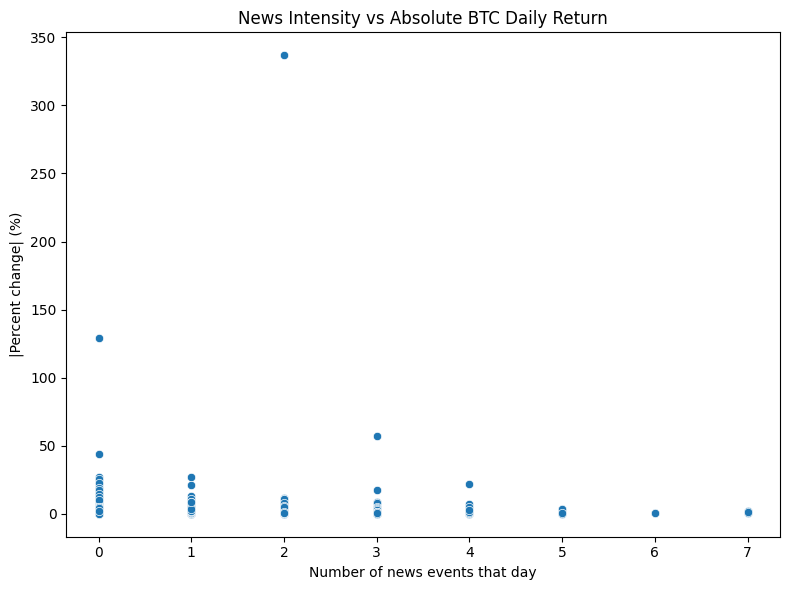

In [ ]:


scatter_df = data.copy()
scatter_df['abs_return'] = scatter_df['percent_change'].abs()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=scatter_df,
                x='news_events_count',
                y='abs_return')

plt.title('News Intensity vs Absolute BTC Daily Return')
plt.xlabel('Number of news events that day')
plt.ylabel('|Percent change| (%)')
plt.tight_layout()
plt.show()


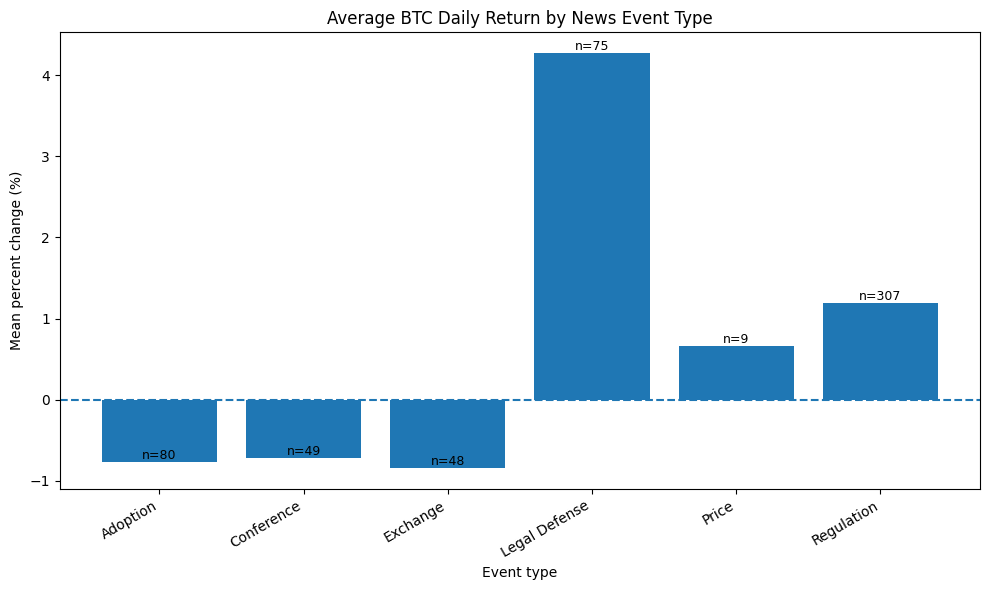

In [ ]:


event_cols = [
    'adoption', 'conference', 'exchange',
    'legal_defense', 'price', 'regulation'
]

# Keep only those event columns that exist in the dataframe
event_cols = [c for c in event_cols if c in data.columns]

avg_returns = []
counts = []

for col in event_cols:
    mask = data[col] == 1
    avg_returns.append(data.loc[mask, 'percent_change'].mean())
    counts.append(mask.sum())

x = np.arange(len(event_cols))

plt.figure(figsize=(10, 6))
bars = plt.bar(x, avg_returns)

plt.xticks(x, [c.replace('_', ' ').title() for c in event_cols], rotation=30, ha='right')
plt.axhline(0, linestyle='--')

plt.title('Average BTC Daily Return by News Event Type')
plt.ylabel('Mean percent change (%)')
plt.xlabel('Event type')

# Optional: annotate bar tops with number of days for each type
for i, (bar, n) in enumerate(zip(bars, counts)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
             height,
             f'n={n}',
             ha='center',
             va='bottom',
             fontsize=9)

plt.tight_layout()
plt.show()


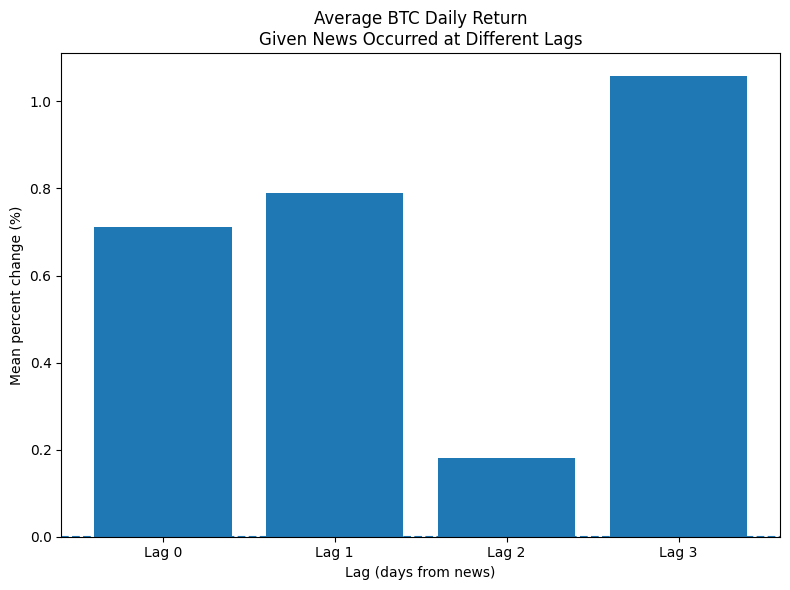

In [ ]:

lag_means = {}
lags = []
means = []

# Lag 0: news on the same day (any news events that day)
if 'news_events_count' in data.columns:
    mask0 = data['news_events_count'] > 0
    lag_means[0] = data.loc[mask0, 'percent_change'].mean()

# Lag 1–3: news in previous days, using lag columns
for lag in [1, 2, 3]:
    col = f'news_event_lag{lag}'
    if col in data.columns:
        mask = data[col] > 0
        lag_means[lag] = data.loc[mask, 'percent_change'].mean()

# Prepare x/y for plotting
for lag, mean_val in sorted(lag_means.items()):
    lags.append(lag)
    means.append(mean_val)

plt.figure(figsize=(8, 6))
plt.bar(lags, means)

plt.xticks(lags, [f'Lag {l}' for l in lags])
plt.axhline(0, linestyle='--')

plt.title('Average BTC Daily Return\nGiven News Occurred at Different Lags')
plt.xlabel('Lag (days from news)')
plt.ylabel('Mean percent change (%)')
plt.tight_layout()
plt.show()


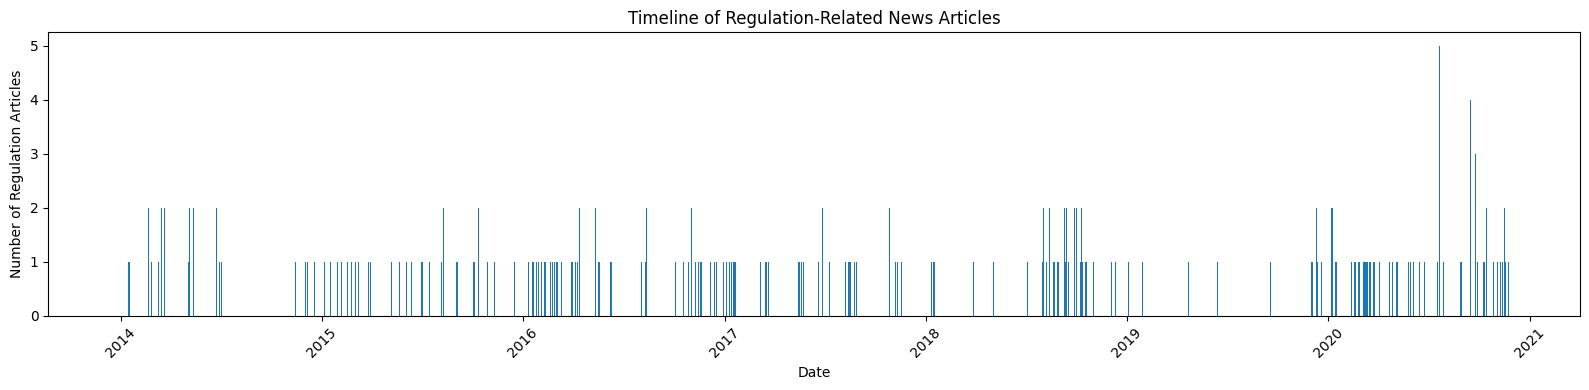

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(16, 4))

plt.bar(
    data['date'],
    data['regulation'],
    width=1.0,
    align='center'
)

plt.title('Timeline of Regulation-Related News Articles')
plt.xlabel('Date')
plt.ylabel('Number of Regulation Articles')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


#Machine Learning: Julius Salas & Usayd Hussein

###**Logistic Regression To Determine If Price Will Increase Or Decrease**

Necessary imports

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Add "classes" to dataset, determine if price increased or decreased

In [ ]:
# 1 for increase, 0 for decrease
ml_data = data.copy()
ml_data['price_increase'] = (ml_data['percent_change'] > 0).astype(int)
ml_data.head()

,ticker,date,open,high,low,close,adoption,conference,exchange,legal_defense,...,regulation,percent_change,range,news_event_happened,news_events_count,news_event_lag1,news_event_lag2,news_event_lag3,regulation_binary,price_increase
0,BTC,2013-12-27,801.98,836.83,767.87,803.05,1.0,0.0,0.0,0.0,...,0.0,0.133420,0.089807,1,1.0,0.0,0.0,0.0,0,1
1,BTC,2013-12-28,803.05,805.97,715.60,761.99,0.0,0.0,0.0,0.0,...,0.0,-5.113007,0.126286,0,0.0,1.0,0.0,0.0,0,0
2,BTC,2013-12-29,761.99,803.95,734.98,784.96,0.0,0.0,0.0,0.0,...,0.0,3.014475,0.093839,0,0.0,0.0,1.0,0.0,0,1
3,BTC,2013-12-30,784.96,818.83,780.96,804.83,0.0,0.0,0.0,0.0,...,0.0,2.531339,0.048492,0,0.0,0.0,0.0,1.0,0,1
4,BTC,2013-12-31,804.83,813.94,776.96,805.94,0.0,0.0,0.0,0.0,...,0.0,0.137917,0.047596,0,0.0,0.0,0.0,0.0,0,1


Next we define our input features (news variables) and output variables for our model

In [ ]:
features = [
    'adoption', 'conference', 'exchange', 'legal_defense', 'regulation',
    'news_event_happened', 'news_events_count',
    'news_event_lag1', 'news_event_lag2', 'news_event_lag3'
]

X = ml_data[features]
y = ml_data['price_increase']

Now we split our dataset into training and tests sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=1, shuffle=False)

print(f"Orginal y size: {y.shape[0]}")
print(f"Train y size: {y_train.shape[0]}")
print(f"Test y size: {y_test.shape[0]}")

Orginal y size: 2527
Train y size: 2021
Test y size: 506


Scale our features

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Now we create our logistic regression model and fit it on the training set

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Now we make a prediction on our testing set

In [ ]:
y_pred = model.predict(X_test)

Now we evalute our model

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.48221343873517786

Confusion Matrix:
 [[ 32 215]
 [ 47 212]]

Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.13      0.20       247
           1       0.50      0.82      0.62       259

    accuracy                           0.48       506
   macro avg       0.45      0.47      0.41       506
weighted avg       0.45      0.48      0.41       506



As expected this model was too simple to determine if Bitcoin prices will increase or decrease. With an accuracy of 0.48 we do not really learn much from this model. Due to Bitcoin having a high volatility and its price being nonlinear, we will have to use more complex models to gain any insight.

###**Linear Regression To Predict Percent Change**

Necessary Imports

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
reg_df = data.copy()
reg_df.head()

,ticker,date,open,high,low,close,adoption,conference,exchange,legal_defense,price,regulation,percent_change,range,news_event_happened,news_events_count,news_event_lag1,news_event_lag2,news_event_lag3,regulation_binary
0,BTC,2013-12-27,801.98,836.83,767.87,803.05,1.0,0.0,0.0,0.0,0.0,0.0,0.133420,0.089807,1,1.0,0.0,0.0,0.0,0
1,BTC,2013-12-28,803.05,805.97,715.60,761.99,0.0,0.0,0.0,0.0,0.0,0.0,-5.113007,0.126286,0,0.0,1.0,0.0,0.0,0
2,BTC,2013-12-29,761.99,803.95,734.98,784.96,0.0,0.0,0.0,0.0,0.0,0.0,3.014475,0.093839,0,0.0,0.0,1.0,0.0,0
3,BTC,2013-12-30,784.96,818.83,780.96,804.83,0.0,0.0,0.0,0.0,0.0,0.0,2.531339,0.048492,0,0.0,0.0,0.0,1.0,0
4,BTC,2013-12-31,804.83,813.94,776.96,805.94,0.0,0.0,0.0,0.0,0.0,0.0,0.137917,0.047596,0,0.0,0.0,0.0,0.0,0


Create Features For Model

In [ ]:
features = ['open', 'high', 'low', 'close', 'adoption', 'conference',
            'exchange', 'legal_defense', 'regulation',
            'news_event_happened', 'news_events_count',
            'news_event_lag1', 'news_event_lag2', 'news_event_lag3']

X = reg_df[features]
y = reg_df['percent_change']

Split Dataset Into Training and Test Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=1, shuffle=False)

print(f"Orginal y size: {y.shape[0]}")
print(f"Train y size: {y_train.shape[0]}")
print(f"Test y size: {y_test.shape[0]}")

Orginal y size: 2527
Train y size: 2021
Test y size: 506


Create Our Model And Make Our Prediction. Then Evaluate The Results

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression")
print(f"Mean Absolute Error: {mae_lr:.4f}")
print(f"Root Mean Squared Error: {rmse_lr:.4f}")

Linear Regression
Mean Absolute Error: 1.4118
Root Mean Squared Error: 2.0515


View Coefficients

In [ ]:
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr_model.coef_})
print(coefficients.sort_values(by='Coefficient', ascending=False))

                Feature  Coefficient
7         legal_defense     6.460230
9   news_event_happened     1.990671
13      news_event_lag3     1.298198
11      news_event_lag1     0.604343
3                 close     0.013316
1                  high     0.001388
2                   low    -0.002830
0                  open    -0.012080
4              adoption    -0.147630
12      news_event_lag2    -0.252199
6              exchange    -0.614574
5            conference    -0.724760
10    news_events_count    -0.819642
8            regulation    -0.833629


###**Random Forest To Predict Percent Change**

Imports

In [ ]:
from sklearn.ensemble import RandomForestRegressor

Create Our Model And Make Our Prediction. Then Evaluate The Results

In [ ]:
rf_model = RandomForestRegressor(random_state=1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest")
print(f"Mean Absolute Error: {mae_rf:.4f}")
print(f"Root Mean Squared Error: {rmse_rf:.4f}")

Random Forest
Mean Absolute Error: 1.1230
Root Mean Squared Error: 1.8377


View Feature Importance

In [ ]:
importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

                Feature  Importance
0                  open    0.513584
2                   low    0.169988
3                 close    0.149544
1                  high    0.076574
7         legal_defense    0.017621
10    news_events_count    0.016820
13      news_event_lag3    0.013399
8            regulation    0.011672
12      news_event_lag2    0.010833
9   news_event_happened    0.009902
11      news_event_lag1    0.007435
5            conference    0.001874
4              adoption    0.000532
6              exchange    0.000223


###**Machine Learning Visualizations And Insights**

Make Bar Graph Showing Effect Of Each Feature

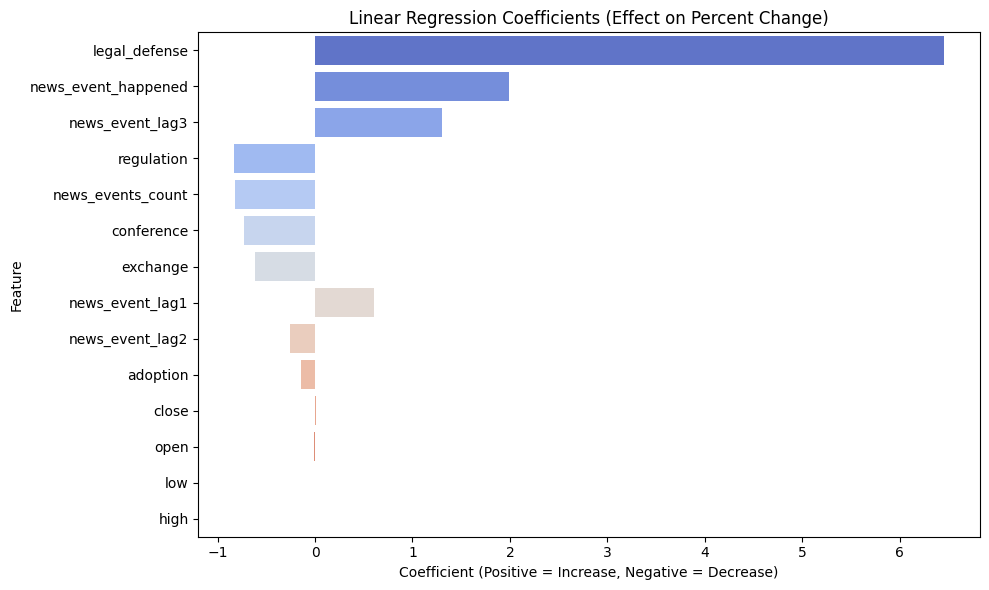

In [ ]:
coeff_sorted = coefficients.sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coeff_sorted, hue='Feature', palette='coolwarm')
plt.title("Linear Regression Coefficients (Effect on Percent Change)")
plt.xlabel("Coefficient (Positive = Increase, Negative = Decrease)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Some things we can learn from this plot are:


*   A news event occuring seems to have a positive impact on the price of Bitcoin (news_event_happned = +1.99). But the more events that occur on a day the worst it is on the price of Bitcoin (news_event_count = -0.82). So while one event might be good for the price, too many can cause the price to drop.
*   Different types of events have different effects on the price of Bitcoin. A legal defense passing has a large postive effect on the price of Bitcoin (+6.46), while events like regulations, conference, and exchange all lower the price.
*   News events seem to orignally have a negative effect on Bitcoin prices (news_event_lag2 = -0.25). However, after some time they might start to have a postivie effect on the price once things have settled (news_event_lag3 = +1.30). This is most likely do to buyers waiting a bit to see how the event effects the price.



Make Bar Plot Showing Most Important Features For Prediction

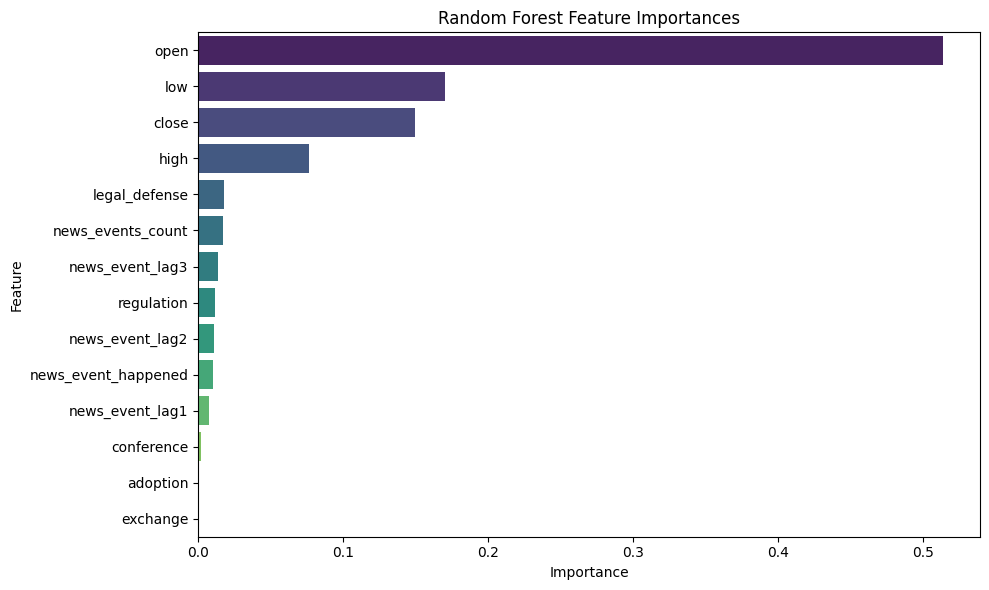

In [ ]:
importance_sorted = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_sorted, hue='Feature', palette='viridis')
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Some things we can learn from this plot are:


*   The most important features when predicting the price of Bitcoin are the price features. Features like open, low, and close all have over 0.1, with open having a value of 0.51. When compared to event features like conference, adoption, exchange that all have values below 0.002. We can see that, while having a small effect, news events do not really help predicting the price of Bitcoin.



#Reflection

###**What is the hardest part of the project that you’ve encountered so far?**

The hardest part was getting the data, particularly the news articles, since we ran into a few issues with the NewsAPI and other APIs that offer news content - a lot of them only go back a few months, whereas we needed news from the past 10 or so years. To solve this, we implemented webscrapping that scrapes news from the Coinbase's web archive that goes back several years from 2014-2020.


###**What are your initial insights?**
Early analysis shows that regulation-related news made up about 12% of all CoinDesk articles, with peaks during major market events like the 2017 ICO boom. Bitcoin’s daily returns were slightly negative on days with regulation news and mildly positive on other days, suggesting that regulatory developments are often viewed as bearish. Periods with more regulation coverage also aligned with higher volatility, indicating that such news tends to accompany or follow major price swings.

###**Are there any concrete results you can show at this point? If not, why not?**
While we have identified some early patterns—such as negative average returns on days with regulation-related news and increased volatility during periods of heavy coverage—these findings are still preliminary. The data collection and cleaning process is ongoing, and we need to complete the alignment between article publication dates and Bitcoin’s price data before drawing statistically valid conclusions. In short, we have promising initial insights, but not yet concrete, verifiable results.

###**Going forward, what are the current biggest problems you’re facing?**
One of our main challenges is ensuring we have sufficient coverage across all years of our dataset. While our current collection of CoinDesk articles from 2014–2020 appears to be sufficient for initial analysis, we would like to expand the dataset to include more recent years. Adding data beyond 2020 would provide a more complete view of how newer regulatory developments—such as the FTX collapse and ETF approvals—may have influenced Bitcoin prices.

###**Do you think you are on track with your project? If not, what parts do you need to dedicate more time to?**
We are meeting the deadlines we set for ourselves during the proposal presentation. Due to the project progress report requiring us to have at least one ML analysis, we were a bit crunched on time with having to code that rather quickly than the 2 weeks we gave our team for that section. Other than that, we are on pace to complete the project.  

###**Given your initial exploration of the data, is it worth proceeding with your project, why? If not, how are you going to change your project and why do you think it’s better than your current results?**
Given our initial exploration, We believe it is worth proceeding with this project. The comparisons between days with and without regulation news show that regulation days behave differently: they occasionally produce very large spikes or crashes, while typical day to day returns look similar once outliers are removed. The bar chart suggests a nonlinear pattern, where only 2 news articles is associated with higher average gains but days with 3+ articles is negative, even if the sample sizes are small. We believe our project gives good insight regarding how regulation news affects bitcoin's value.


#Next Steps
Our next actions will be focused on expanding and enhancing our dataset in order to increase the reliability of our results. To prevent discrepancies that can skew the results of our machine learning analysis, we will keep cleaning the data by matching publication timestamps with Bitcoin price data. To find out if regulatory news has a significant impact on daily returns, we can run additional statistical tests once the dataset is complete. In order to determine whether regulatory features can forecast favorable or unfavorable price movements, we will also start developing and assessing machine learning models, such as logistic regression. In addition, we will produce additional visualizations that illustrate patterns in sentiment, volatility, price reactions, and article frequency. Lastly, we will begin creating the last notebook and presentation materials that will summarize our approach, results, and limitations.

#Generative AI Suggestions
GenAI tools could support the remaining work in several helpful but non-substantive ways. They can be used to summarize long regulatory articles into concise descriptions, which may assist in categorizing each event by policy type or regulatory theme. GenAI could also propose additional feature ideas for our machine learning models, such as topic classifications, that the team can manually validate. For coding tasks, GenAI may help draft template code for scraping, cleaning, visualization, or creating ML pipelines, which we will refine to ensure accuracy. Additionally, GenAI could offer suggestions for effective ways to visualize the relationship between news coverage and Bitcoin’s volatility. Finally, it may assist with drafting sections of the final report, such as background explanations or discussions of limitations, while all analysis and conclusions remain human sourced.